# Who Delegates to AI? — Replication code

Archive of the analysis code submitted with the paper. The notebook is organized to
run top to bottom:

1. **Imports** — all modules used anywhere in the notebook, gathered here.
2. **Data & merge** — build a single `merged_df` keyed on `soc_code`, starting from the
   Agentic Adoption Index (`aai_index.csv`) and merging in every column the analysis uses:
   Frey–Osborne computerisation risk, 2010 / 2025 BLS employment and wages, typical
   entry education, the three comparison exposure measures (GPT availability, Gemini RL
   capability, Claude usage), and the O*NET cognitive-ability share. Duplicates are
   removed on `soc_code` during the merge.
3. **Analysis** — ordered to follow the manuscript's *Analytic strategy* / *Results*:
   5.1 pre-AI automation risk, 5.2 comparison with existing exposure measures, and
   5.3 wages and education.
4. **SI — state / sector** — left as in the original submission.


## Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

from scipy import stats
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter1d

import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

import plotly.graph_objects as go
from plotly.subplots import make_subplots

SEED = 42
np.random.seed(SEED)

## Data and merge

Every source is loaded, reduced to the columns the analysis needs, and merged onto the
AAI table by `soc_code`. `merged_df` is deduplicated on `soc_code` so that each
occupation appears once.

In [2]:
# ── Base: Agentic Adoption Index (one row per occupation) ──
occ_mean = pd.read_csv('/home/lhch9550/국민 연구/aai_index.csv')
occ_mean = occ_mean.rename(columns={'O*NET-SOC Code': 'soc_code'})

# ── Frey & Osborne (2017) pre-AI computerisation probability ──
frey_df = pd.read_csv('/home/lhch9550/직업_학제성_연구/frey_osborne_2017_appendix.csv')
frey_df = frey_df.rename(columns={'probability': 'frey_probability'})

# aai_index를 base로: 모든 aai 직업을 살리고, frey는 있으면 붙임
merged_df = occ_mean.merge(frey_df, on='soc_code', how='left')

# frey에 없는 직업은 occupation이 비므로 aai 테이블의 title로 채움
merged_df['occupation'] = merged_df['occupation'].fillna(merged_df['title'])

# ── Claude usage: observed exposure (Massenkoff & McCrory, 2026) ──
claude_df = pd.read_csv('/home/lhch9550/직업_학제성_연구/claude.csv')
claude_agg = claude_df.groupby(['O*NET-SOC Code', 'Title']).agg(
    claude_usage=('pct', 'mean'),
).reset_index()
claude_agg['soc_code'] = claude_agg['O*NET-SOC Code'].str[:7]
claude_agg = claude_agg[['soc_code', 'claude_usage']]
merged_df = merged_df.merge(claude_agg, on='soc_code', how='left')

# ── BLS 2025: employment, median wage ──
df_2025 = pd.read_excel('/home/lhch9550/직업_학제성_연구/national_M2025_dl.xlsx')
df_2025 = df_2025[['OCC_CODE', 'TOT_EMP', 'A_MEDIAN']].copy()
df_2025.columns = ['soc_code', 'employment_2025', 'median_wage_2025']
df_2025 = df_2025[df_2025['soc_code'].str.match(r'^\d{2}-\d{4}$', na=False)].reset_index(drop=True)
df_2025['employment_2025']  = pd.to_numeric(df_2025['employment_2025'],  errors='coerce')
df_2025['median_wage_2025'] = pd.to_numeric(df_2025['median_wage_2025'], errors='coerce')
merged_df = merged_df.merge(df_2025, on='soc_code', how='left')

# ── BLS 2010: employment, median wage ──
df_2010 = pd.read_excel('/home/lhch9550/직업_학제성_연구/national_M2010_dl.xls')
df_2010 = df_2010[['OCC_CODE', 'TOT_EMP', 'A_MEDIAN']].copy()
df_2010.columns = ['soc_code', 'employment_2010', 'median_wage_2010']
df_2010 = df_2010[df_2010['soc_code'].str.match(r'^\d{2}-\d{4}$', na=False)].reset_index(drop=True)
df_2010['employment_2010']  = pd.to_numeric(df_2010['employment_2010'],  errors='coerce')
df_2010['median_wage_2010'] = pd.to_numeric(df_2010['median_wage_2010'], errors='coerce')
merged_df = merged_df.merge(df_2010, on='soc_code', how='left')

# ── Typical entry-level education (BLS Employment Matrix) ──
occupation_info = pd.read_csv('/home/lhch9550/직업_학제성_연구/occupation.csv')
occupation_info = occupation_info[['2024 National Employment Matrix code',
                                   'Typical education needed for entry']].copy()
occupation_info = occupation_info.rename(columns={
    '2024 National Employment Matrix code': 'soc_code',
    'Typical education needed for entry':   'education_level',
})
merged_df = merged_df.merge(occupation_info, on='soc_code', how='left')

# ── GPT availability exposure (Eloundou et al., 2024) ──
gpt_df = pd.read_csv('/home/lhch9550/직업_학제성_연구/occ_level.csv')
gpt_df['soc_code'] = gpt_df['O*NET-SOC Code'].str.split('.').str[0]
gpt_cols = ['dv_rating_alpha', 'dv_rating_beta', 'dv_rating_gamma',
            'human_rating_alpha', 'human_rating_beta', 'human_rating_gamma']
merged_df = merged_df.merge(gpt_df[['soc_code'] + gpt_cols], on='soc_code', how='left')

# ── Deduplicate on soc_code (keep first), as in the original pipeline ──
merged_df = merged_df.drop_duplicates(subset='soc_code', keep='first').reset_index(drop=True)

# ── Gemini RL feasibility: capability exposure (Tomei & Klein Teeselink, 2026) ──
RL_df = pd.read_csv('/home/lhch9550/국민 연구/RL_index.csv')
rl_agg = RL_df.groupby('O*NET-SOC Code')['gemini_rl_index'].mean().reset_index()
rl_agg.columns = ['soc_code', 'rl_feasibility']
rl_agg['soc_code'] = rl_agg['soc_code'].str.replace(r'\.00$', '', regex=True)
merged_df = merged_df.merge(rl_agg, on='soc_code', how='left')

# ── O*NET cognitive-ability share ──
ability_df = pd.read_excel('/home/lhch9550/직업_학제성_연구/Abilities.xlsx')
ability_im = ability_df[ability_df['Scale ID'] == 'IM'].copy()   # Importance scale only

# Cognitive ability elements (O*NET content model 1.A.1 subtree)
cognitive_ids = [
    '1.A.1.a.1', '1.A.1.a.2', '1.A.1.a.3', '1.A.1.a.4',
    '1.A.1.b.1', '1.A.1.b.2', '1.A.1.b.3', '1.A.1.b.4',
    '1.A.1.b.5', '1.A.1.b.6', '1.A.1.b.7',
    '1.A.1.c.1', '1.A.1.c.2',
    '1.A.1.d.1',
    '1.A.1.e.1', '1.A.1.e.2', '1.A.1.e.3',
    '1.A.1.f.1', '1.A.1.f.2',
    '1.A.1.g.1', '1.A.1.g.2',
]
ability_im['is_cognitive'] = ability_im['Element ID'].isin(cognitive_ids)
ability_agg = ability_im.groupby('O*NET-SOC Code').apply(
    lambda x: pd.Series({
        'cognitive_ability_share':
            x.loc[x['is_cognitive'], 'Data Value'].sum() / x['Data Value'].sum(),
    })
).reset_index()
ability_agg['O*NET-SOC Code'] = ability_agg['O*NET-SOC Code'].str.replace(r'\.00$', '', regex=True)
ability_agg = ability_agg.rename(columns={'O*NET-SOC Code': 'soc_code'})
merged_df = merged_df.merge(ability_agg, on='soc_code', how='left')

# ── Final dedup on soc_code + save ──
merged_df = merged_df.drop_duplicates(subset='soc_code', keep='first').reset_index(drop=True)
merged_df.to_csv('/home/lhch9550/국민 연구/merged_df.csv', index=False)

merged_df

,soc_code,title,aai,aai_manus,rank,frey_probability,label,occupation,claude_usage,employment_2025,...,median_wage_2010,education_level,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma,rl_feasibility,cognitive_ability_share
0,11-1011,Chief Executives,0.139885,0.148602,70.0,0.015,0.0,Chief executives,0.031911,204350.0,...,165080.0,Bachelor's degree,0.100000,0.460000,0.820000,0.180000,0.350000,0.520000,13.896774,0.587906
1,11-1021,General and Operations Managers,0.139522,0.153998,195.0,0.160,NaN,General and operations managers,0.031075,3503020.0,...,94400.0,Bachelor's degree,0.000000,0.480769,0.961538,0.115385,0.384615,0.653846,23.382353,0.556844
2,11-1031,Legislators,NaN,NaN,NaN,NaN,NaN,Legislators,0.005233,NaN,...,19260.0,Bachelor's degree,0.033333,0.400000,0.766667,0.266667,0.516667,0.766667,NaN,NaN
3,11-2011,Advertising and Promotions Managers,0.128269,0.149791,124.0,0.039,NaN,Advertising and promotions managers,0.017601,21470.0,...,83890.0,Bachelor's degree,0.000000,0.476744,0.953488,0.255814,0.546512,0.837209,33.871429,0.584141
4,11-2021,Marketing Managers,0.122668,0.141684,61.0,0.014,NaN,Marketing managers,0.013003,395240.0,...,112800.0,Bachelor's degree,0.062500,0.500000,0.937500,0.218750,0.578125,0.937500,32.020000,0.588047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,53-7071,Gas Compressor and Gas Pumping Station Operators,0.108079,0.109085,549.0,0.910,NaN,Gas compressor and gas pumping station operators,NaN,3510.0,...,50590.0,High school diploma or equivalent,0.230769,0.269231,0.307692,0.000000,0.076923,0.153846,31.300000,0.425777
770,53-7072,"Pump Operators, Except Wellhead Pumpers",0.110642,0.112991,542.0,0.900,NaN,"Pump operators, except wellhead pumpers",0.001954,9780.0,...,43740.0,High school diploma or equivalent,0.166667,0.250000,0.333333,0.000000,0.166667,0.333333,19.442857,0.424612
771,53-7073,Wellhead Pumpers,0.092211,0.090533,480.0,0.840,NaN,Wellhead pumpers,NaN,17990.0,...,40640.0,High school diploma or equivalent,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.107143,0.417503
772,53-7081,Refuse and Recyclable Material Collectors,0.099506,0.094674,585.0,0.930,NaN,Refuse and recyclable material collectors,NaN,147240.0,...,32640.0,No formal educational credential,0.178571,0.196429,0.214286,0.107143,0.232143,0.357143,15.864286,0.371185


In [3]:
merged_df = pd.read_csv('/home/lhch9550/국민 연구/merged_df.csv')
merged_df = merged_df.drop_duplicates(subset='soc_code', keep='first').reset_index(drop=True)
merged_df

,soc_code,title,aai,aai_manus,rank,frey_probability,label,occupation,claude_usage,employment_2025,...,median_wage_2010,education_level,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma,rl_feasibility,cognitive_ability_share
0,11-1011,Chief Executives,0.139885,0.148602,70.0,0.015,0.0,Chief executives,0.031911,204350.0,...,165080.0,Bachelor's degree,0.100000,0.460000,0.820000,0.180000,0.350000,0.520000,13.896774,0.587906
1,11-1021,General and Operations Managers,0.139522,0.153998,195.0,0.160,NaN,General and operations managers,0.031075,3503020.0,...,94400.0,Bachelor's degree,0.000000,0.480769,0.961538,0.115385,0.384615,0.653846,23.382353,0.556844
2,11-1031,Legislators,NaN,NaN,NaN,NaN,NaN,Legislators,0.005233,NaN,...,19260.0,Bachelor's degree,0.033333,0.400000,0.766667,0.266667,0.516667,0.766667,NaN,NaN
3,11-2011,Advertising and Promotions Managers,0.128269,0.149791,124.0,0.039,NaN,Advertising and promotions managers,0.017601,21470.0,...,83890.0,Bachelor's degree,0.000000,0.476744,0.953488,0.255814,0.546512,0.837209,33.871429,0.584141
4,11-2021,Marketing Managers,0.122668,0.141684,61.0,0.014,NaN,Marketing managers,0.013003,395240.0,...,112800.0,Bachelor's degree,0.062500,0.500000,0.937500,0.218750,0.578125,0.937500,32.020000,0.588047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,53-7071,Gas Compressor and Gas Pumping Station Operators,0.108079,0.109085,549.0,0.910,NaN,Gas compressor and gas pumping station operators,NaN,3510.0,...,50590.0,High school diploma or equivalent,0.230769,0.269231,0.307692,0.000000,0.076923,0.153846,31.300000,0.425777
770,53-7072,"Pump Operators, Except Wellhead Pumpers",0.110642,0.112991,542.0,0.900,NaN,"Pump operators, except wellhead pumpers",0.001954,9780.0,...,43740.0,High school diploma or equivalent,0.166667,0.250000,0.333333,0.000000,0.166667,0.333333,19.442857,0.424612
771,53-7073,Wellhead Pumpers,0.092211,0.090533,480.0,0.840,NaN,Wellhead pumpers,NaN,17990.0,...,40640.0,High school diploma or equivalent,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.107143,0.417503
772,53-7081,Refuse and Recyclable Material Collectors,0.099506,0.094674,585.0,0.930,NaN,Refuse and recyclable material collectors,NaN,147240.0,...,32640.0,No formal educational credential,0.178571,0.196429,0.214286,0.107143,0.232143,0.357143,15.864286,0.371185


In [4]:
measures = {
    'Agentic Adoption Index':               'aai',
    'Tomei & Teeselink (2026) (Gemini)':    'rl_feasibility',
    'Eloundou et al. (2024) (GPT-4)':       'dv_rating_gamma',
    'Massenkoff & McCrory (2026) (Claude)': 'claude_usage',
}

desc_base = merged_df.drop_duplicates(subset='soc_code', keep='first')

rows = {}
for label, col in measures.items():
    s = desc_base[col].dropna()
    rows[label] = {
        'N':         int(s.shape[0]),
        'Mean':      s.mean(),
        'Min':       s.min(),
        '25th pct':  s.quantile(0.25),
        'Median':    s.median(),
        '75th pct':  s.quantile(0.75),
        'Max':       s.max(),
    }

table3 = pd.DataFrame(rows).T[['N', 'Mean', 'Min', '25th pct', 'Median', '75th pct', 'Max']]

fmt = table3.copy()
fmt['N'] = fmt['N'].astype(int)
for c in ['Mean', 'Min', '25th pct', 'Median', '75th pct', 'Max']:
    fmt[c] = fmt[c].map(lambda v: f'{v:.2f}')

print(fmt.to_string())

                                        N   Mean   Min 25th pct Median 75th pct    Max
Agentic Adoption Index                748   0.11  0.04     0.09   0.11     0.12   0.19
Tomei & Teeselink (2026) (Gemini)     748  25.60  0.00    13.07  24.92    35.85  69.42
Eloundou et al. (2024) (GPT-4)        774   0.51  0.00     0.17   0.50     0.84   1.00
Massenkoff & McCrory (2026) (Claude)  502   0.02  0.00     0.00   0.01     0.02   0.23


### Derived columns and analysis subsets

Employment counts (thousands → persons), log wage, the three-tier education grouping, and
the SOC major-group label. `df_base_edu` is the estimation sample for the wage/education
figures.

In [7]:
# ── SOC major group ──
major_group_map = {
    '11': 'Management Occupations',
    '13': 'Business and Financial Operations Occupations',
    '15': 'Computer and Mathematical Occupations',
    '17': 'Architecture and Engineering Occupations',
    '19': 'Life, Physical, and Social Science Occupations',
    '21': 'Community and Social Service Occupations',
    '23': 'Legal Occupations',
    '25': 'Educational Instruction and Library Occupations',
    '27': 'Arts, Design, Entertainment, Sports, and Media Occupations',
    '29': 'Healthcare Practitioners and Technical Occupations',
    '31': 'Healthcare Support Occupations',
    '33': 'Protective Service Occupations',
    '35': 'Food Preparation and Serving Related Occupations',
    '37': 'Building and Grounds Cleaning and Maintenance Occupations',
    '39': 'Personal Care and Service Occupations',
    '41': 'Sales and Related Occupations',
    '43': 'Office and Administrative Support Occupations',
    '45': 'Farming, Fishing, and Forestry Occupations',
    '47': 'Construction and Extraction Occupations',
    '49': 'Installation, Maintenance, and Repair Occupations',
    '51': 'Production Occupations',
    '53': 'Transportation and Material Moving Occupations',
}
merged_df['major_group'] = merged_df['soc_code'].str[:2].map(major_group_map)

# ── Employment: thousands → persons ──
merged_df['employment_2025_n'] = pd.to_numeric(
    merged_df['employment_2025'].astype(str).str.replace(',', ''), errors='coerce') * 1000
merged_df['employment_2010_n'] = pd.to_numeric(
    merged_df['employment_2010'].astype(str).str.replace(',', ''), errors='coerce') * 1000

# ── Log wage ──
merged_df['log_wage'] = np.log(merged_df['median_wage_2025'])

# ── Education: 3 tiers ──
edu_map = {
    'No formal educational credential':  'High school or below',
    'High school diploma or equivalent': 'High school or below',
    'Some college, no degree':           'High school or below',
    'Postsecondary nondegree award':     'High school or below',
    "Bachelor's degree":                 "Bachelor's degree",
    "Master's degree":                   "Master's or above",
    'Doctoral or professional degree':   "Master's or above",
}
merged_df['edu3'] = merged_df['education_level'].map(edu_map)

# ── Estimation sample for the wage / education figures ──
cols_base = ['aai', 'frey_probability', 'log_wage', 'human_rating_gamma']
df_base_edu = merged_df.dropna(subset=cols_base + ['edu3']).copy()

## 5.1  Agentic adoption does not follow pre-AI automation risk

Split occupations at the AAI median and compare with the Frey–Osborne high/low-risk
partition via the Jaccard coefficient, then plot the two measures against each other
(Figure 3).

In [6]:
prob_col = "frey_probability"    # Frey-Osborne automation probability
aai_col  = "aai"

print(f"probability non-null: {merged_df[prob_col].notna().sum():,} / {len(merged_df):,}")

d = merged_df.dropna(subset=[prob_col, aai_col]).copy()
print(f"Valid occupations (both present): {len(d):,}")

# Automation: probability >= 0.5 -> high(1). AAI: binarize at median
d["auto_high"] = (d[prob_col] >= 0.5).astype(int)
aai_med = d[aai_col].median()
print(f"AAI median: {aai_med:.4f}")
d["aai_high"] = (d[aai_col] >= aai_med).astype(int)

# Jaccard: intersection / union of the two "high" sets
a = d["auto_high"].astype(bool)
b = d["aai_high"].astype(bool)
intersection = (a & b).sum()
union        = (a | b).sum()
jaccard = intersection / union if union else float("nan")

print(f"\nauto_high(prob>=0.5): {a.sum():,} / aai_high: {b.sum():,}")
print(f"Intersection: {intersection:,} / Union: {union:,}")
print(f"Jaccard similarity: {jaccard:.4f}")

probability non-null: 607 / 774
Valid occupations (both present): 606
AAI median: 0.1083

auto_high(prob>=0.5): 360 / aai_high: 303
Intersection: 167 / Union: 496
Jaccard similarity: 0.3367


**Figure 3.** AAI versus computerization risk across occupations.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


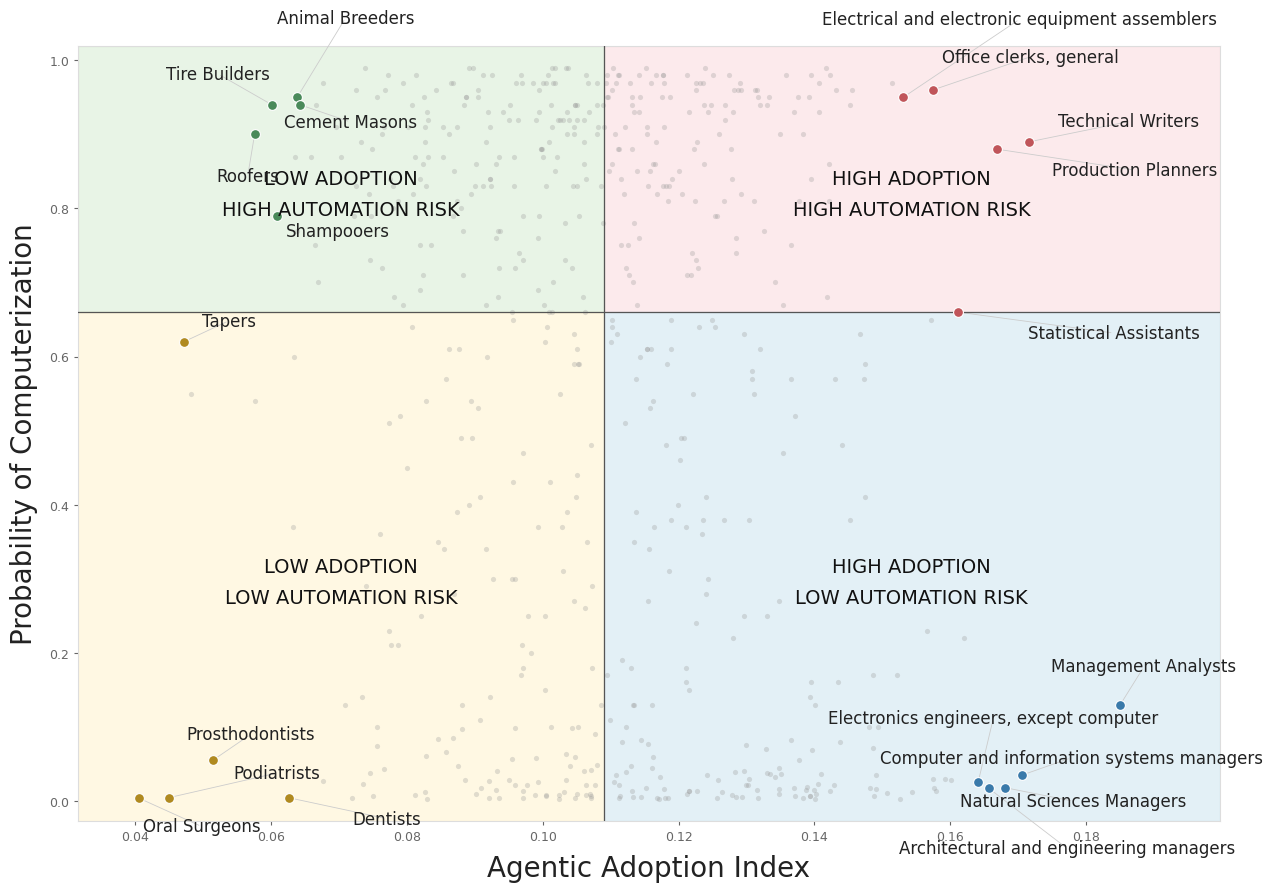

In [7]:
short_occ = {
    'Chemical plant and system operators': 'Chemical Plant Operators',
    'Cutting and slicing machine setters, operators, and tenders': 'Cutting Machine Operators',
    'Electronic home entertainment equipment installers and repairers': 'Electronics Repairers',
    'Stationary engineers and boiler operators': 'Boiler Operators',
    'Electrical and electronics drafters': 'Electronics Drafters',
    'Tax examiners and collectors, and revenue agents': 'Tax Examiners',
    'Tire repairers and changers': 'Tire Repairers',
    'Animal breeders': 'Animal Breeders',
    'Terrazzo workers and finishers': 'Terrazzo Workers',
    'Paving, surfacing, and tamping equipment operators': 'Paving Equipment Operators',
    'Judges, magistrate judges, and magistrates': 'Judges & Magistrates',
    'Makeup artists, theatrical and performance': 'Makeup Artists',
    'Dentists, general': 'Dentists',
    'Crossing guards': 'Crossing Guards',
    'Zoologists and wildlife biologists': 'Wildlife Biologists',
    'Training and development managers': 'Training Managers',
    'Marriage and family therapists': 'Family Therapists',
    'Court, municipal, and license clerks': 'Municipal Clerks',
    'Social and human service assistants': 'Social Service Assistants',
    'Mechanical engineering technicians': 'Mechanical Technicians',
    'Technical writers': 'Technical Writers',
    'Production, planning, and expediting clerks': 'Production Planners',
    'Statistical assistants': 'Statistical Assistants',
    'Office clerks, general': 'Office Clerks',
    'Secretaries and administrative assistants, except legal, medical, and executive': 'Secretaries & Admins',
    'Roofers': 'Roofers',
    'Tire builders': 'Tire Builders',
    'Shampooers': 'Shampooers',
    'Floor sanders and finishers': 'Floor Sanders',
    'Cement masons and concrete finishers': 'Cement Masons',
    'Oral and maxillofacial surgeons': 'Oral Surgeons',
    'Podiatrists': 'Podiatrists',
    'Tapers': 'Tapers',
    'Prosthodontists': 'Prosthodontists',
    'Automotive glass installers and repairers': 'Auto Glass Repairers',
    'Management analysts': 'Management Analysts',
    'Natural sciences managers': 'Natural Sciences Managers',
    'Industrial production managers': 'Industrial Prod. Managers',
    'First-line supervisors of office and administrative support workers': 'Office Supervisors',
    'Industrial engineers': 'Industrial Engineers',
    'Office Clerks, General': 'Office Clerks',
    'First-Line Supervisors of Office and Administrative Support Workers': 'Office Supervisors',
}

merged_df_reset = merged_df.reset_index(drop=True)

x_med = merged_df_reset['aai'].median()
y_med = merged_df_reset['frey_probability'].median()

q1 = merged_df_reset[(merged_df_reset['aai'] >= x_med) & (merged_df_reset['frey_probability'] >= y_med)]
q2 = merged_df_reset[(merged_df_reset['aai'] <  x_med) & (merged_df_reset['frey_probability'] >= y_med)]
q3 = merged_df_reset[(merged_df_reset['aai'] <  x_med) & (merged_df_reset['frey_probability'] <  y_med)]
q4 = merged_df_reset[(merged_df_reset['aai'] >= x_med) & (merged_df_reset['frey_probability'] <  y_med)]

def pick_extreme(df, n=5):
    dx = (df['aai'] - x_med) / merged_df_reset['aai'].std()
    dy = (df['frey_probability'] - y_med) / merged_df_reset['frey_probability'].std()
    dist = (dx**2 + dy**2) ** 0.5
    return df.loc[dist.nlargest(n).index]

bg = {'q1': '#fadadd', 'q2': '#d6ecd2', 'q3': '#fff3cc', 'q4': '#cce5f0'}
q_dot_colors = {'q1': '#c0555a', 'q2': '#4a8a5a', 'q3': '#b08a20', 'q4': '#3a7aaa'}

xmin, xmax = merged_df_reset['aai'].min(), merged_df_reset['aai'].max()
ymin, ymax = merged_df_reset['frey_probability'].min(), merged_df_reset['frey_probability'].max()
x_pad = (xmax - xmin) * 0.06
y_pad = (ymax - ymin) * 0.03
xl, xr = xmin - x_pad, xmax + x_pad
yb, yt = ymin - y_pad, ymax + y_pad

fig, ax = plt.subplots(figsize=(13, 9), facecolor='white')
ax.set_facecolor('white')

ax.fill_between([x_med, xr], y_med, yt, color=bg['q1'], alpha=0.55, zorder=0)
ax.fill_between([xl,  x_med], y_med, yt, color=bg['q2'], alpha=0.55, zorder=0)
ax.fill_between([xl,  x_med], yb,  y_med, color=bg['q3'], alpha=0.55, zorder=0)
ax.fill_between([x_med, xr],  yb,  y_med, color=bg['q4'], alpha=0.55, zorder=0)

ax.scatter(merged_df_reset['aai'], merged_df_reset['frey_probability'],
           color='#999999', s=14, alpha=0.3, linewidths=0, zorder=3)

labeled_dfs = {k: pick_extreme(q)
               for k, q in [('q1',q1),('q2',q2),('q3',q3),('q4',q4)]}

texts = []
for key, ldf in labeled_dfs.items():
    ax.scatter(ldf['aai'], ldf['frey_probability'],
               color=q_dot_colors[key], s=50, zorder=5,
               edgecolors='white', linewidths=0.8)
    for _, row in ldf.iterrows():
        label = short_occ.get(row['occupation'], ' '.join(row['occupation'].split()))
        texts.append(ax.text(row['aai'], row['frey_probability'], label,
                             fontsize=12, color='#222222', zorder=7))

adjust_text(
    texts, ax=ax,
    x=merged_df_reset['aai'].values,
    y=merged_df_reset['frey_probability'].values,
    expand=(1.5, 1.8),
    arrowprops=dict(arrowstyle='-', color='#cccccc', lw=0.6),
    xlims=(xl, xr), ylims=(yb, yt),
    force_text=(0.8, 1.0), force_points=(0.5, 0.8),
)

ax.axvline(x_med, color='#555555', linestyle='-', linewidth=0.9, zorder=4)
ax.axhline(y_med, color='#555555', linestyle='-', linewidth=0.9, zorder=4)

dy = (yt - yb) * 0.04
quadrant_labels = [
    (x_med + (xr-x_med)/2, (y_med + yt)/2, 'HIGH ADOPTION', 'HIGH AUTOMATION RISK', 'q1'),
    (xl    + (x_med-xl)/2, (y_med + yt)/2, 'LOW ADOPTION',  'HIGH AUTOMATION RISK', 'q2'),
    (xl    + (x_med-xl)/2, (yb    + y_med)/2, 'LOW ADOPTION',  'LOW AUTOMATION RISK',  'q3'),
    (x_med + (xr-x_med)/2, (yb    + y_med)/2, 'HIGH ADOPTION', 'LOW AUTOMATION RISK',  'q4'),
]
for x, y, line1, line2, key in quadrant_labels:
    ax.text(x, y,      line1, fontsize=14, color='#111111', ha='center', va='center', zorder=6)
    ax.text(x, y - dy, line2, fontsize=14, color='#111111', ha='center', va='center', zorder=6)

ax.set_xlabel('Agentic Adoption Index', fontsize=20, color='#222222', labelpad=8)
ax.set_ylabel('Probability of Computerization', fontsize=20, color='#222222', labelpad=8)
ax.set_xlim(xl, xr)
ax.set_ylim(yb, yt)
ax.tick_params(colors='#666666', labelsize=9, length=3)
for spine in ax.spines.values():
    spine.set_color('#dddddd')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('fig_quadrant.png', dpi=300, bbox_inches='tight', pad_inches=0.1, facecolor='white')
plt.show()

**Employment distribution across the two measures (2010 vs 2025).** Left: employment
over the Frey–Osborne probability with 2010 employment; right: employment over the AAI with
2025 employment.

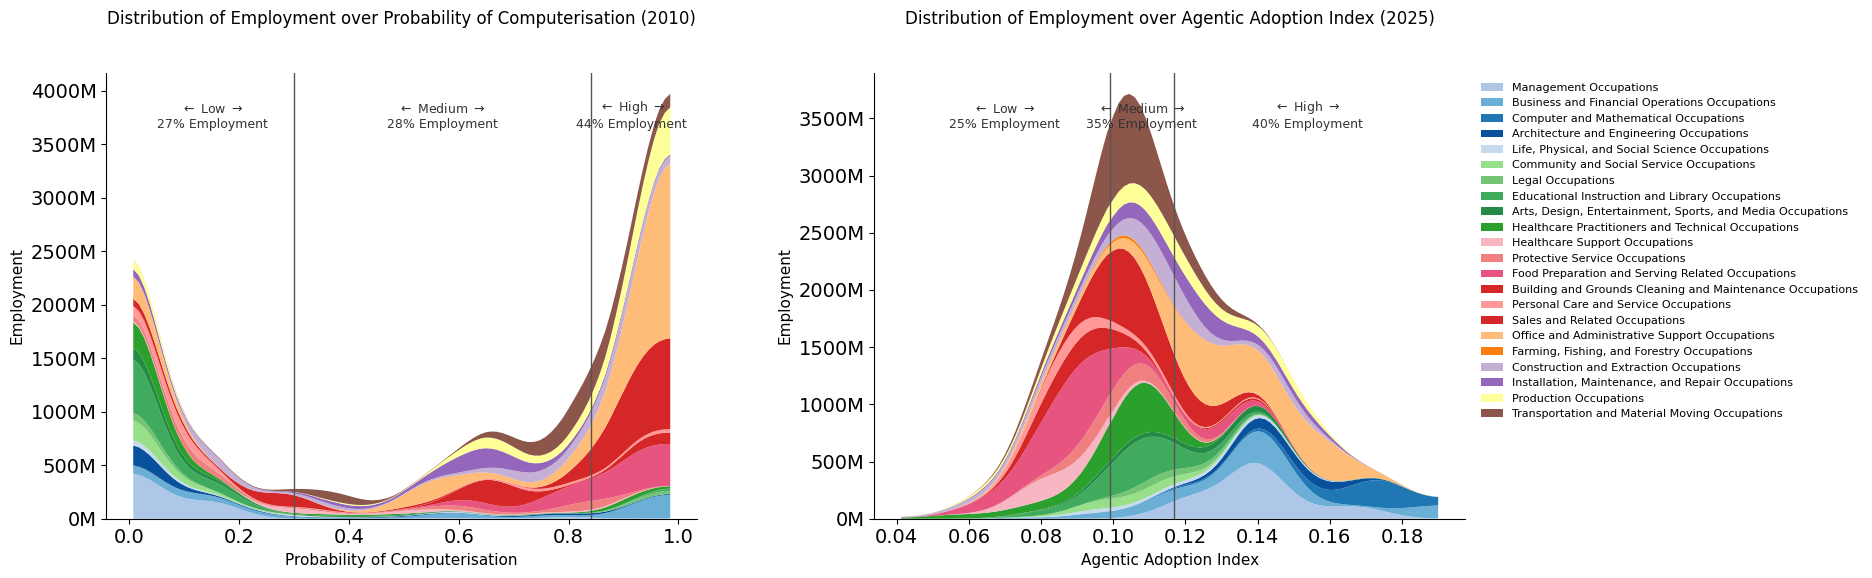

In [13]:
colors = {
    'Management Occupations':                                    '#aec6e8',
    'Business and Financial Operations Occupations':             '#6baed6',
    'Computer and Mathematical Occupations':                     '#1f77b4',
    'Architecture and Engineering Occupations':                  '#08519c',
    'Life, Physical, and Social Science Occupations':            '#c6dbef',
    'Community and Social Service Occupations':                  '#98df8a',
    'Legal Occupations':                                         '#74c476',
    'Educational Instruction and Library Occupations':           '#41ab5d',
    'Arts, Design, Entertainment, Sports, and Media Occupations':'#238b45',
    'Healthcare Practitioners and Technical Occupations':        '#2ca02c',
    'Healthcare Support Occupations':                            '#f7b6c2',
    'Protective Service Occupations':                            '#f08080',
    'Food Preparation and Serving Related Occupations':          '#e75480',
    'Building and Grounds Cleaning and Maintenance Occupations': '#d62728',
    'Personal Care and Service Occupations':                     '#ff9896',
    'Sales and Related Occupations':                             '#d62728',
    'Office and Administrative Support Occupations':             '#ffbb78',
    'Farming, Fishing, and Forestry Occupations':                '#ff7f0e',
    'Construction and Extraction Occupations':                   '#c5b0d5',
    'Installation, Maintenance, and Repair Occupations':         '#9467bd',
    'Production Occupations':                                    '#ffff99',
    'Transportation and Material Moving Occupations':            '#8c564b',
}

n_bins      = 100
sigma       = 5
group_order = list(colors.keys())

def plot_employment_dist(ax, df, x_col, emp_col, title, xlabel):
    df_tmp = df.dropna(subset=[x_col, emp_col, 'major_group']).copy()

    low_thresh  = df_tmp[x_col].quantile(0.33)
    high_thresh = df_tmp[x_col].quantile(0.67)

    df_tmp['bin'] = pd.cut(df_tmp[x_col], bins=n_bins)
    grp = df_tmp.groupby(['bin', 'major_group'])[emp_col].sum().unstack(fill_value=0)
    grp.index = [interval.mid for interval in grp.index]
    grp = grp.sort_index()
    for col in grp.columns:
        grp[col] = gaussian_filter1d(grp[col].values.astype(float), sigma=sigma)

    total    = df_tmp[emp_col].sum()
    low_pct  = df_tmp[df_tmp[x_col] <= low_thresh][emp_col].sum() / total * 100
    mid_pct  = df_tmp[(df_tmp[x_col] > low_thresh) &
                      (df_tmp[x_col] <= high_thresh)][emp_col].sum() / total * 100
    high_pct = df_tmp[df_tmp[x_col] > high_thresh][emp_col].sum() / total * 100

    existing = [g for g in group_order if g in grp.columns]
    ax.stackplot(grp.index, [grp[g] for g in existing],
                 labels=existing, colors=[colors[g] for g in existing])

    y_max = grp.sum(axis=1).max()
    x_min = df_tmp[x_col].min()
    x_max = df_tmp[x_col].max()

    ax.axvline(low_thresh,  color='#555555', linestyle='-', linewidth=1)
    ax.axvline(high_thresh, color='#555555', linestyle='-', linewidth=1)
    for x, label, pct in [
        ((x_min + low_thresh) / 2,        'Low',    low_pct),
        ((low_thresh + high_thresh) / 2,  'Medium', mid_pct),
        ((high_thresh + x_max) / 2,       'High',   high_pct),
    ]:
        ax.text(x, y_max * 0.92,
                f'$\\leftarrow$ {label} $\\rightarrow$\n{pct:.0f}% Employment',
                ha='center', fontsize=9, color='#333333')

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Employment', fontsize=11)
    ax.set_title(title, fontsize=12, pad=35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')
for ax in axes.flat:
    ax.set_facecolor('white')

plot_employment_dist(axes[0], merged_df, 'frey_probability', 'employment_2010_n',
                     'Distribution of Employment over Probability of Computerisation (2010)',
                     'Probability of Computerisation')
plot_employment_dist(axes[1], merged_df, 'aai', 'employment_2025_n',
                     'Distribution of Employment over Agentic Adoption Index (2025)',
                     'Agentic Adoption Index')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1.0),
               ncol=1, fontsize=8, frameon=False)

plt.tight_layout()
plt.subplots_adjust(right=0.82, wspace=0.3)
plt.savefig('fig_distribution_git.png', dpi=300)
plt.show()

## 5.2  The AAI aligns with capability more than with observed use

Spearman correlations between the AAI and the three comparison measures — capability
(Gemini RL), availability (GPT γ), and observed use (Claude) — in Figure 4, followed by
the cognitive-ability-share validation (Figure S1).

**Figure 4.** Correlation between the AAI and established exposure measures.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


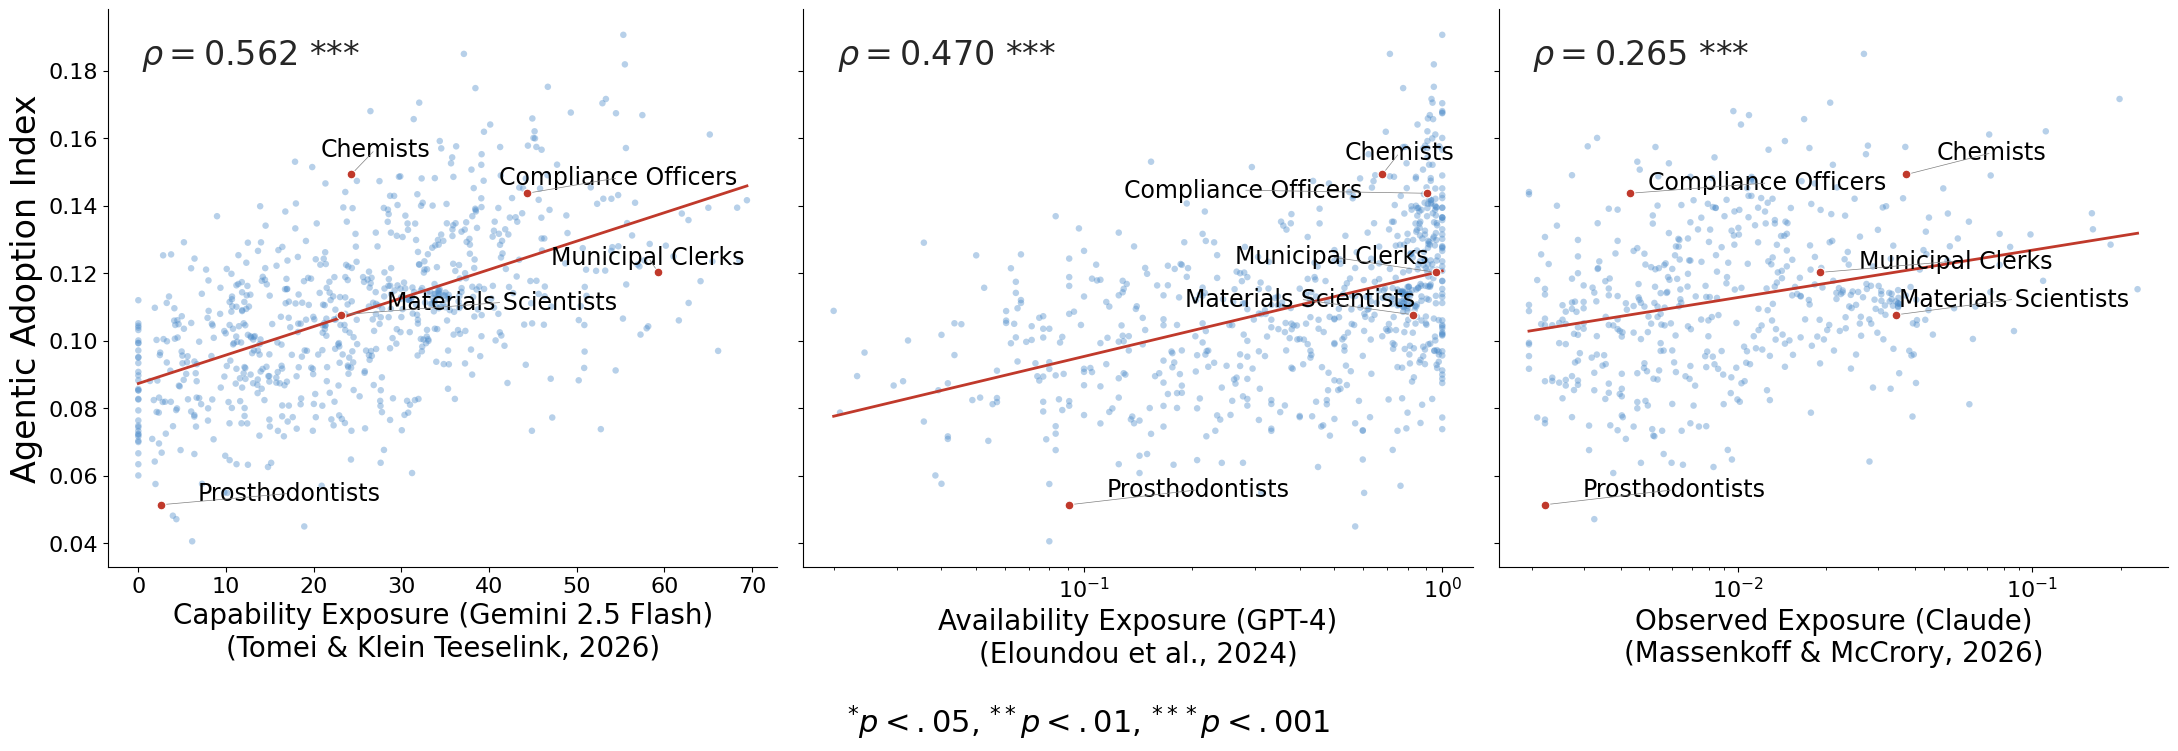

In [8]:
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

cols = ['rl_feasibility', 'dv_rating_gamma', 'claude_usage']
xlabels = {
    'rl_feasibility':  'Capability Exposure (Gemini 2.5 Flash)\n(Tomei & Klein Teeselink, 2026)',
    'dv_rating_gamma': r'Availability Exposure (GPT-4)' + '\n(Eloundou et al., 2024)',
    'claude_usage':    'Observed Exposure (Claude)\n(Massenkoff & McCrory, 2026)',
}
short_names = {
    'Prosthodontists': 'Prosthodontists',
    'Materials scientists': 'Materials Scientists',
    'Court, municipal, and license clerks': 'Municipal Clerks',
    'Compliance oﬃcers': 'Compliance Officers',
    'Chemists': 'Chemists',
}
NAME_COL  = 'occupation'
INDEX_COL = 'aai'

base = merged_df[[NAME_COL, INDEX_COL] + cols].dropna()
base = base[base['claude_usage'] > 0]
label_df = base[base[NAME_COL].isin(short_names.keys())]

plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

for i, (ax, col) in enumerate(zip(axes, cols)):
    corr_df = merged_df[[INDEX_COL, col]].dropna()
    if col in ['claude_usage', 'dv_rating_gamma']:
        corr_df = corr_df[corr_df[col] > 0]
        log_x = np.log10(corr_df[col])
        ax.set_xscale('log')
    else:
        log_x = corr_df[col]

    # Spearman is rank-based, so it is invariant to the log transform.
    rho, p = stats.spearmanr(corr_df[col], corr_df[INDEX_COL])

    ax.scatter(corr_df[col], corr_df[INDEX_COL],
               alpha=0.4, s=22, color='#4C8BC9', edgecolor='none')

    m, b = np.polyfit(log_x, corr_df[INDEX_COL], 1)
    if col in ['claude_usage', 'dv_rating_gamma']:
        x_line = np.logspace(log_x.min(), log_x.max(), 100)
        ax.plot(x_line, m * np.log10(x_line) + b, color='#C0392B', linewidth=2)
    else:
        x_line = np.linspace(log_x.min(), log_x.max(), 100)
        ax.plot(x_line, m * x_line + b, color='#C0392B', linewidth=2)

    ld = label_df[label_df[col] > 0] if col in ['claude_usage', 'dv_rating_gamma'] else label_df.dropna(subset=[col])
    ax.scatter(ld[col], ld[INDEX_COL],
               s=40, color='#C0392B', edgecolor='white', linewidth=0.8, zorder=5)

    texts = [ax.text(r[col], r[INDEX_COL],
                     short_names.get(r[NAME_COL], r[NAME_COL]), fontsize=17)
             for _, r in ld.iterrows()]
    adjust_text(texts, ax=ax, seed=SEED,
                arrowprops=dict(arrowstyle='-', color='0.5', lw=0.5))

    ax.text(0.05, 0.95, rf'$\it{{\rho = {rho:.3f}}}$ {sig_stars(p)}',
            transform=ax.transAxes, ha='left', va='top', fontsize=24, alpha=0.85)
    ax.set_xlabel(xlabels[col], fontsize=20)
    if i == 0:
        ax.set_ylabel('Agentic Adoption Index', fontsize=24)
    ax.tick_params(labelsize=16)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.text(0.5, -0.02, r'$^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$',
         ha='center', va='top', fontsize=22)
plt.savefig('fig_validation.png', dpi=300, bbox_inches='tight')
plt.show()

**Figure S1.** The AAI is positively correlated with the cognitive-ability share.

Pearson r (cognitive_ability_share): r = 0.4267, p = 1.92e-34


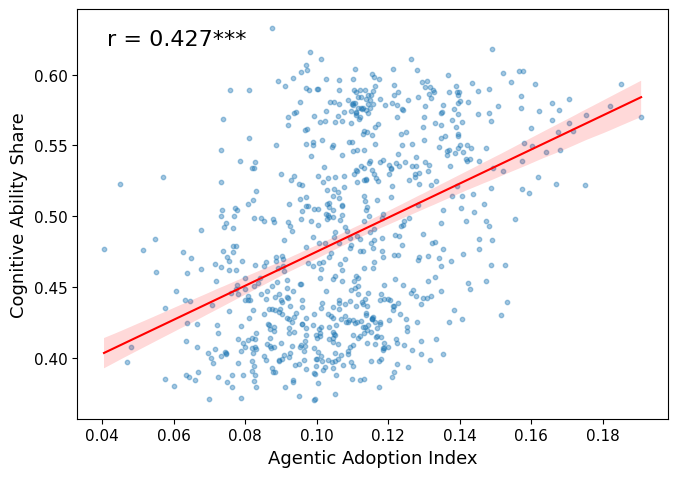

In [9]:
temp = merged_df[['aai', 'cognitive_ability_share']].dropna()
r, p = pearsonr(temp['aai'], temp['cognitive_ability_share'])
print(f"Pearson r (cognitive_ability_share): r = {r:.4f}, p = {p:.2e}")

sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=temp, x='aai', y='cognitive_ability_share',
            scatter_kws={'alpha': 0.4, 's': 10},
            line_kws={'color': 'red', 'linewidth': 1.5}, ax=ax)
ax.set_xlabel('Agentic Adoption Index', fontsize=13)
ax.set_ylabel('Cognitive Ability Share', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.text(0.05, 0.95, f'r = {r:.3f}{sig}', transform=ax.transAxes,
        fontsize=16, verticalalignment='top')

plt.tight_layout()
plt.savefig('ability_share_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.3  Adoption rises with wages, except among the most-educated

Employment-weighted WLS regressions of the AAI on wages, education, and availability
exposure (Table 4), then the predicted-AAI figure from Model 4 (Figure 5). The SI
robustness table (Table S3) swaps in the alternative exposure measures.

**Table 4.** WLS regressions of the Agentic Adoption Index.

In [10]:
cols_m1 = ['aai', 'log_wage', 'edu3', 'employment_2025_n']
cols_m2 = ['aai', 'dv_rating_gamma', 'employment_2025_n']
cols_m3 = ['aai', 'dv_rating_gamma', 'log_wage', 'edu3', 'employment_2025_n']
cols_m4 = ['aai', 'dv_rating_gamma', 'log_wage', 'edu3', 'employment_2025_n']

df_m1 = merged_df.dropna(subset=cols_m1).copy()
df_m2 = merged_df.dropna(subset=cols_m2).copy()
df_m3 = merged_df.dropna(subset=cols_m3).copy()
df_m4 = merged_df.dropna(subset=cols_m4).copy()

edu_term = "C(edu3, Treatment(\"Bachelor's degree\"))"

# (1) wage + education
model_1 = smf.wls(f"aai ~ log_wage + {edu_term}",
                  weights=df_m1['employment_2025_n'], data=df_m1).fit()
# (2) gamma
model_2 = smf.wls("aai ~ dv_rating_gamma",
                  weights=df_m2['employment_2025_n'], data=df_m2).fit()
# (3) full (gamma + wage + education)
model_3 = smf.wls(f"aai ~ dv_rating_gamma + log_wage + {edu_term}",
                  weights=df_m3['employment_2025_n'], data=df_m3).fit()
# (4) full + wage × education interaction
model_4 = smf.wls(f"aai ~ dv_rating_gamma + log_wage * {edu_term}",
                  weights=df_m4['employment_2025_n'], data=df_m4).fit()

row_order = [
    'Intercept',
    'dv_rating_gamma',
    'log_wage',
    f"{edu_term}[T.High school or below]",
    f"{edu_term}[T.Master's or above]",
    f"log_wage:{edu_term}[T.High school or below]",
    f"log_wage:{edu_term}[T.Master's or above]",
]
rename_mapper = {
    'Intercept':                                              'Intercept',
    'dv_rating_gamma':                                        'Availability Exposure (gamma)',
    'log_wage':                                               'log wage',
    f"{edu_term}[T.High school or below]":                    'High school or below',
    f"{edu_term}[T.Master's or above]":                       "Master's or above",
    f"log_wage:{edu_term}[T.High school or below]":           'log wage × High school or below',
    f"log_wage:{edu_term}[T.Master's or above]":              "log wage × Master's or above",
}

table = summary_col(
    [model_1, model_2, model_3, model_4],
    model_names=['(1)', '(2)', '(3)', '(4)'],
    stars=True, float_format='%.3f', drop_omitted=False,
    regressor_order=row_order,
    info_dict={
        'N':       lambda x: f"{int(x.nobs)}",
        'R²':      lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}",
    },
)
table.tables[0].index = [rename_mapper.get(i, i) for i in table.tables[0].index]
print(table)


                                   (1)      (2)       (3)       (4)   
----------------------------------------------------------------------
Intercept                       -0.278*** 0.089*** -0.149*** -0.303***
                                (0.031)   (0.001)  (0.028)   (0.047)  
Availability Exposure (gamma)             0.048*** 0.038***  0.038*** 
                                          (0.002)  (0.002)   (0.002)  
log wage                        0.036***           0.022***  0.035*** 
                                (0.003)            (0.002)   (0.004)  
High school or below            0.002              0.008***  0.159*** 
                                (0.003)            (0.002)   (0.057)  
Master's or above               -0.031***          -0.025*** 0.620*** 
                                (0.004)            (0.003)   (0.096)  
log wage × High school or below                              -0.013***
                                                             (0.005)  
log w

**Figure 5.** Predicted AAI across wage and education, both panels from Model 4.

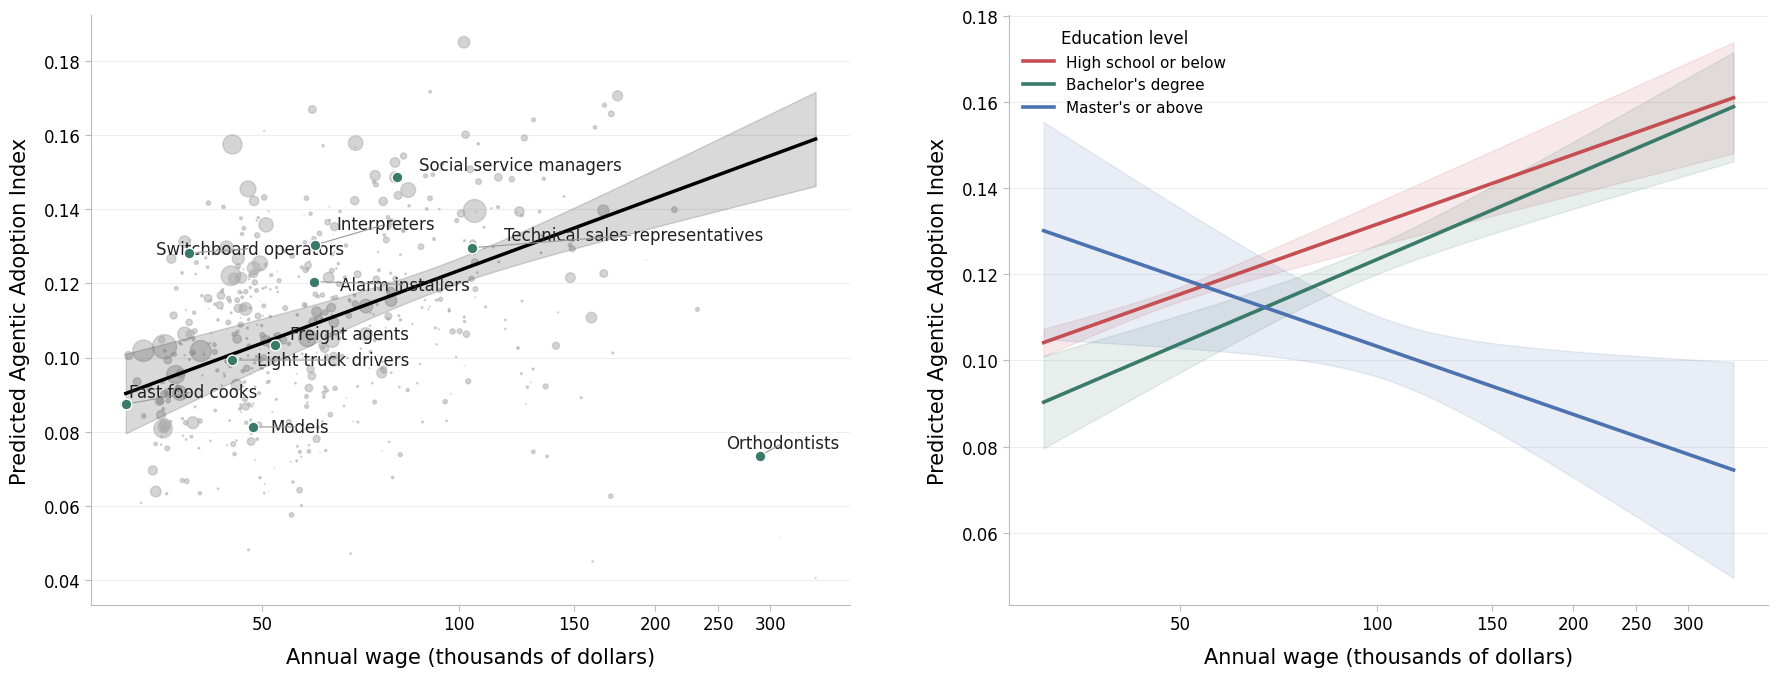

In [11]:
GAMMA_COL  = 'dv_rating_gamma'
edu3_order = ["High school or below", "Bachelor's degree", "Master's or above"]
edu_colors = {
    "High school or below": '#c44e52',
    "Bachelor's degree":    '#3a7a6a',
    "Master's or above":    '#4c72b0',
}
short_names = {
    'Cooks, fast food': 'Fast food cooks',
    'Switchboard operators, including answering service': 'Switchboard operators',
    'Light truck or delivery services drivers': 'Light truck drivers',
    'Models': 'Models',
    'Jewelers and precious stone and metal workers': 'Jewelers',
    'Interpreters and translators': 'Interpreters',
    'Crane and tower operators': 'Crane operators',
    'Social and community service managers': 'Social service managers',
    'Sales representatives, wholesale and manufacturing, technical and scientific products': 'Technical sales representatives',
    'Orthodontists': 'Orthodontists',
    'First-line supervisors of construction trades and extraction workers': 'Construction supervisors',
    'Security and fire alarm systems installers': 'Alarm installers',
    'Cargo and freight agents': 'Freight agents',
    'Electronic equipment installers and repairers, motor vehicles': 'Auto electronics repairers',
}

# ── Data ──
df = df_base_edu.copy()
df['wage'] = np.exp(df['log_wage'])
df = df.dropna(subset=['employment_2025_n', 'log_wage', 'aai', GAMMA_COL, 'edu3']).copy()
df = df[df['edu3'].isin(edu3_order)].copy().reset_index(drop=True)

emp = df['employment_2025_n'].values
edu_term = "C(edu3, Treatment(\"Bachelor's degree\"))"

# ── Model 4 (log_wage × edu3 interaction) — used for both panels ──
model4 = smf.wls(f"aai ~ {GAMMA_COL} + log_wage * {edu_term}",
                 weights=df['employment_2025_n'], data=df).fit()

gamma_bar = np.average(df[GAMMA_COL].values, weights=emp)
lw_min, lw_max = df['log_wage'].min(), df['log_wage'].max()
lw_grid = np.linspace(lw_min, lw_max, 300)

xs_raw = df['log_wage'].values
ys_raw = df['aai'].values
xr_span = xs_raw.max() - xs_raw.min()
yr_span = ys_raw.max() - ys_raw.min()

# Panel 1: edu = reference (Bachelor's)
pred_df = pd.DataFrame({'log_wage': lw_grid, GAMMA_COL: gamma_bar, 'edu3': "Bachelor's degree"})
pred = model4.get_prediction(pred_df).summary_frame(alpha=0.05)
yhat, ci_lo, ci_hi = pred['mean'].values, pred['mean_ci_lower'].values, pred['mean_ci_upper'].values

# Panel 2: per-education slopes
edu_lines = {}
for e in edu3_order:
    pdf = pd.DataFrame({'log_wage': lw_grid, GAMMA_COL: gamma_bar, 'edu3': e})
    pr = model4.get_prediction(pdf).summary_frame(alpha=0.05)
    edu_lines[e] = (pr['mean'].values, pr['mean_ci_lower'].values, pr['mean_ci_upper'].values)

# Label selection (left panel)
df_label_pool = df.dropna(subset=['occupation']).copy()
priority_idx = df_label_pool.index[df_label_pool['occupation'].isin(short_names.keys())].tolist()

def thin_by_distance(indices, xs, ys, min_dx, min_dy):
    kept = []
    for i in indices:
        if all(not (abs(xs[i] - xs[j]) < min_dx and abs(ys[i] - ys[j]) < min_dy) for j in kept):
            kept.append(i)
    return kept

label_idx = thin_by_distance(priority_idx, xs_raw, ys_raw,
                             min_dx=xr_span * 0.06, min_dy=yr_span * 0.06)
size_scaled = (emp / emp.max()) * 300

wage_ticks_k = [50, 100, 150, 200, 250, 300]
tick_positions = [np.log(k * 1000) for k in wage_ticks_k]
keep = [(p, k) for p, k in zip(tick_positions, wage_ticks_k)
        if lw_min - 0.05 <= p <= lw_max + 0.05]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='white', sharey=False)

# Panel 1
ax = axes[0]
ax.set_facecolor('white')
ax.scatter(xs_raw, ys_raw, alpha=0.5, s=size_scaled, color='#aaaaaa', zorder=1)
ax.fill_between(lw_grid, ci_lo, ci_hi, color='black', alpha=0.15, zorder=2)
ax.plot(lw_grid, yhat, color='black', linewidth=2.5, zorder=3)

texts = []
for i in label_idx:
    ax.scatter(xs_raw[i], ys_raw[i], s=60, color='#3a7a6a', zorder=5,
               edgecolors='white', linewidths=1.0)
    texts.append(ax.text(xs_raw[i], ys_raw[i],
                         short_names.get(df.loc[i, 'occupation'], df.loc[i, 'occupation']),
                         fontsize=12, color='#222222'))
adjust_text(texts, ax=ax,
            only_move={'points': 'xy', 'text': 'xy'},
            expand_text=(1.4, 1.6), expand_points=(1.6, 1.8),
            force_text=(0.6, 0.9), force_points=(0.5, 0.8),
            lim=500, arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8))

ax.set_xticks([p for p, _ in keep]); ax.set_xticklabels([str(k) for _, k in keep])
ax.set_xlabel('Annual wage (thousands of dollars)', fontsize=15, labelpad=10)
ax.set_ylabel('Predicted Agentic Adoption Index', fontsize=15, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=12, length=4, color='#bbbbbb')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color('#bbbbbb'); ax.spines['bottom'].set_color('#bbbbbb')
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0); ax.set_axisbelow(True)

# Panel 2
ax2 = axes[1]
ax2.set_facecolor('white')
for e in edu3_order:
    mean, lo, hi = edu_lines[e]
    c = edu_colors[e]
    ax2.fill_between(lw_grid, lo, hi, color=c, alpha=0.12, zorder=2)
    ax2.plot(lw_grid, mean, color=c, linewidth=2.6, zorder=3, label=e)

ax2.set_xticks([p for p, _ in keep]); ax2.set_xticklabels([str(k) for _, k in keep])
ax2.set_xlabel('Annual wage (thousands of dollars)', fontsize=15, labelpad=10)
ax2.set_ylabel('Predicted Agentic Adoption Index', fontsize=15, labelpad=10)
ax2.tick_params(axis='both', which='major', labelsize=12, length=4, color='#bbbbbb')
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines['left'].set_color('#bbbbbb'); ax2.spines['bottom'].set_color('#bbbbbb')
ax2.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0); ax2.set_axisbelow(True)
ax2.legend(title='Education level', fontsize=11, title_fontsize=12, frameon=False, loc='best')

plt.tight_layout(w_pad=4)
plt.savefig('fig_model4_bothpanels.png', dpi=300,
            bbox_inches='tight', pad_inches=0.1, facecolor='white')
plt.show()

**Table S3.** Robustness: the same specifications with each alternative exposure measure.

In [12]:
cols_si = ['aai', 'log_wage',
           'dv_rating_alpha', 'dv_rating_gamma', 'rl_feasibility', 'claude_usage',
           'employment_2025_n']

df_si     = merged_df.dropna(subset=cols_si).copy()
df_si_edu = merged_df.dropna(subset=cols_si + ['edu3']).copy()
df_claude     = merged_df.dropna(subset=['aai', 'claude_usage', 'log_wage', 'employment_2025_n']).copy()
df_claude_edu = merged_df.dropna(subset=['aai', 'claude_usage', 'log_wage', 'edu3', 'employment_2025_n']).copy()

EDU = "C(edu3, Treatment(\"Bachelor's degree\"))"

model_s1 = smf.wls("aai ~ dv_rating_alpha",
                   weights=df_si['employment_2025_n'], data=df_si).fit()
model_s2 = smf.wls(f"aai ~ dv_rating_alpha + log_wage * {EDU}",
                   weights=df_si_edu['employment_2025_n'], data=df_si_edu).fit()
model_s3 = smf.wls("aai ~ dv_rating_gamma",
                   weights=df_si['employment_2025_n'], data=df_si).fit()
model_s4 = smf.wls(f"aai ~ dv_rating_gamma + log_wage * {EDU}",
                   weights=df_si_edu['employment_2025_n'], data=df_si_edu).fit()
model_s5 = smf.wls("aai ~ rl_feasibility",
                   weights=df_si['employment_2025_n'], data=df_si).fit()
model_s6 = smf.wls(f"aai ~ rl_feasibility + log_wage * {EDU}",
                   weights=df_si_edu['employment_2025_n'], data=df_si_edu).fit()
model_s7 = smf.wls("aai ~ claude_usage",
                   weights=df_claude['employment_2025_n'], data=df_claude).fit()
model_s8 = smf.wls(f"aai ~ claude_usage + log_wage * {EDU}",
                   weights=df_claude_edu['employment_2025_n'], data=df_claude_edu).fit()

hs = f"{EDU}[T.High school or below]"
ma = f"{EDU}[T.Master's or above]"
row_order_si = [
    'Intercept', 'log_wage',
    'dv_rating_alpha', 'dv_rating_gamma', 'rl_feasibility', 'claude_usage',
    hs, ma,
    f'log_wage:{hs}', f'log_wage:{ma}',
]
rename_mapper = {
    'Intercept':       'Intercept',
    'log_wage':        'log wage',
    'dv_rating_alpha': 'alpha (GPT)',
    'dv_rating_gamma': 'gamma (GPT)',
    'rl_feasibility':  'RL Feasibility (Gemini)',
    'claude_usage':    'Claude usage',
    hs:                'High school or below',
    ma:                "Master's or above",
    f'log_wage:{hs}':  'log wage × High school or below',
    f'log_wage:{ma}':  "log wage × Master's or above",
}

table_si = summary_col(
    [model_s1, model_s2, model_s3, model_s4, model_s5, model_s6, model_s7, model_s8],
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)', '(7)', '(8)'],
    stars=True, float_format='%.3f', drop_omitted=False,
    regressor_order=row_order_si,
    info_dict={
        'N':       lambda x: f"{int(x.nobs)}",
        'R²':      lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}",
    },
)
table_si.tables[0].index = [rename_mapper.get(i, i) for i in table_si.tables[0].index]
print(table_si)


                                  (1)       (2)      (3)       (4)      (5)       (6)      (7)       (8)   
-----------------------------------------------------------------------------------------------------------
Intercept                       0.111*** -0.310*** 0.090*** -0.202*** 0.091*** -0.296*** 0.112*** -0.293***
                                (0.001)  (0.061)   (0.002)  (0.056)   (0.002)  (0.054)   (0.001)  (0.063)  
log wage                                 0.038***           0.026***           0.035***           0.036*** 
                                         (0.005)            (0.005)            (0.005)            (0.005)  
alpha (GPT)                     0.046*** 0.060***                                                          
                                (0.007)  (0.006)                                                           
gamma (GPT)                                        0.045*** 0.037***                                       
                           

## SI — State-level analysis

Left as in the original submission, with the merge keys updated to `aai` /
`frey_probability`. State-level employment-weighted AAI and computerisation risk, their
standardized deviations from the national average (choropleths), and their cross-state
correlation.

In [23]:
state_df = pd.read_excel('/home/lhch9550/국민 연구/state_M2025_dl.xlsx')
state_df.columns

Index(['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE',
       'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP',
       'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT',
       'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN',
       'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75',
       'A_PCT90', 'ANNUAL', 'HOURLY'],
      dtype='object')

In [24]:
merged_temp = merged_df[['frey_probability', 'soc_code', 'aai']]
merged_temp

,frey_probability,soc_code,aai
0,0.015,11-1011,0.139885
1,0.160,11-1021,0.139522
2,NaN,11-1031,NaN
3,0.039,11-2011,0.128269
4,0.014,11-2021,0.122668
...,...,...,...
769,0.910,53-7071,0.108079
770,0.900,53-7072,0.110642
771,0.840,53-7073,0.092211
772,0.930,53-7081,0.099506


In [25]:
state_df['soc_code'] = state_df['OCC_CODE'].str.replace(r'\.00$', '', regex=True)

state_merged = state_df.merge(merged_temp, on='soc_code', how='left')
state_merged = state_merged.dropna(subset=['aai']).reset_index(drop=True)
state_merged

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,soc_code,frey_probability,aai
0,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,101670,134650,166420,222490,317400,NaN,NaN,11-1011,0.015,0.139885
1,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,55160,76840,111790,169510,243600,NaN,NaN,11-1021,0.160,0.139522
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-2011,Advertising and Promotions Managers,...,60000,62500,64640,143210,213860,NaN,NaN,11-2011,0.039,0.128269
3,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-2021,Marketing Managers,...,70790,89950,120160,164800,225300,NaN,NaN,11-2021,0.014,0.122668
4,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-2022,Sales Managers,...,66050,87490,124040,167200,218270,NaN,NaN,11-2022,0.013,0.121547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31697,78,Virgin Islands,3,VI,0,Cross-industry,cross-industry,1235,53-7051,Industrial Truck and Tractor Operators,...,27190,31030,35230,43420,52600,NaN,NaN,53-7051,0.930,0.121495
31698,78,Virgin Islands,3,VI,0,Cross-industry,cross-industry,1235,53-7061,Cleaners of Vehicles and Equipment,...,22230,26360,28290,31190,36610,NaN,NaN,53-7061,0.370,0.099311
31699,78,Virgin Islands,3,VI,0,Cross-industry,cross-industry,1235,53-7062,"Laborers and Freight, Stock, and Material Move...",...,26620,28150,31810,37410,38940,NaN,NaN,53-7062,0.850,0.101765
31700,78,Virgin Islands,3,VI,0,Cross-industry,cross-industry,1235,53-7064,"Packers and Packagers, Hand",...,21890,21960,22880,27200,35510,NaN,NaN,53-7064,0.380,0.126656


In [26]:
state_level = state_merged[state_merged['AREA_TYPE'] == 2].copy()
state_level['TOT_EMP'] = pd.to_numeric(state_level['TOT_EMP'], errors='coerce')
state_level = state_level.dropna(subset=['aai', 'frey_probability', 'TOT_EMP'])

# National employment-weighted averages
national_avg_aai  = np.average(state_level['aai'],              weights=state_level['TOT_EMP'])
national_avg_prob = np.average(state_level['frey_probability'], weights=state_level['TOT_EMP'])

# Per-state aggregation
state_agg = state_level.groupby('PRIM_STATE').apply(
    lambda x: pd.Series({
        'aai_weighted':          np.average(x['aai'],              weights=x['TOT_EMP']),
        'probability_weighted':  np.average(x['frey_probability'], weights=x['TOT_EMP']),
    })
).reset_index()

state_agg['aai_deviation']  = state_agg['aai_weighted']         - national_avg_aai
state_agg['prob_deviation'] = state_agg['probability_weighted'] - national_avg_prob
state_agg.columns = ['state'] + list(state_agg.columns[1:])

print(f"National avg AAI:  {national_avg_aai:.4f}")
print(f"National avg Prob: {national_avg_prob:.4f}")
state_agg.sort_values('aai_deviation', ascending=False)

National avg AAI:  0.1150
National avg Prob: 0.5746


,state,aai_weighted,probability_weighted,aai_deviation,prob_deviation
7,DC,0.120083,0.432329,0.005074,-0.142264
19,MA,0.116877,0.505634,0.001868,-0.068960
20,MD,0.116333,0.543167,0.001324,-0.031426
43,TX,0.116235,0.563498,0.001226,-0.011095
30,NH,0.116207,0.570775,0.001199,-0.003819
6,CT,0.116147,0.530957,0.001139,-0.043636
45,VA,0.115996,0.559041,0.000987,-0.015553
44,UT,0.115866,0.573291,0.000857,-0.001302
22,MI,0.115819,0.581887,0.000810,0.007294
31,NJ,0.115733,0.562546,0.000725,-0.012047


In [27]:
state_agg['aai_dev_std']  = state_agg['aai_deviation']  / state_level['aai'].std()
state_agg['prob_dev_std'] = state_agg['prob_deviation'] / state_level['frey_probability'].std()

Z_LIM = 0.2  # fixed color scale limit for sharper contrast

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Agentic Adoption Index (Standardized)',
                    'Computerization Risk (Standardized)'),
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]],
)

fig.add_trace(
    go.Choropleth(
        locations=state_agg['state'], locationmode='USA-states',
        z=state_agg['aai_dev_std'], colorscale='RdBu_r',
        zmid=0, zmin=-Z_LIM, zmax=Z_LIM, showscale=False, name='AAI',
    ),
    row=1, col=1,
)
fig.add_trace(
    go.Choropleth(
        locations=state_agg['state'], locationmode='USA-states',
        z=state_agg['prob_dev_std'], colorscale='RdBu_r',
        zmid=0, zmin=-Z_LIM, zmax=Z_LIM,
        colorbar=dict(title='Std. Deviation', x=1.0, tickformat='.2f'), name='Prob',
    ),
    row=1, col=2,
)

fig.update_geos(scope='usa')
fig.update_layout(height=450, width=1200)
fig.show()

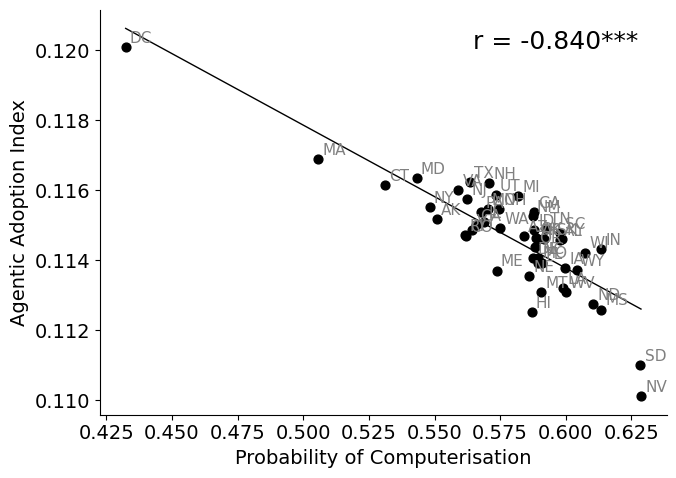

In [28]:
r, p = stats.pearsonr(state_agg['probability_weighted'], state_agg['aai_weighted'])
slope, intercept, _, _, _ = stats.linregress(state_agg['probability_weighted'],
                                             state_agg['aai_weighted'])

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(state_agg['probability_weighted'], state_agg['aai_weighted'],
           color='black', s=40, zorder=3)
for _, row in state_agg.iterrows():
    ax.annotate(row['state'], (row['probability_weighted'], row['aai_weighted']),
                fontsize=11, color='grey', xytext=(3, 3), textcoords='offset points')

x_range = np.linspace(state_agg['probability_weighted'].min(),
                      state_agg['probability_weighted'].max(), 100)
ax.plot(x_range, slope * x_range + intercept, color='black', linewidth=1, linestyle='-')

ax.set_xlabel('Probability of Computerisation')
ax.set_ylabel('Agentic Adoption Index')
ax.text(0.95, 0.95, f'r = {r:.3f}{p_to_stars(p)}',
        transform=ax.transAxes, fontsize=18, va='top', ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig('fig_si_state_2.png', dpi=300, bbox_inches='tight')
plt.show()